In [1]:
# Import Libraries
import numpy as np
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt
from matplotlib import rcParams
import time
from datetime import datetime

# PyTorch and PyTorch Geometric
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import TransformerConv, global_mean_pool, BatchNorm
from torch_geometric.data import Data, DataLoader
from torch_geometric.utils import dense_to_sparse

# Sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.spatial.distance import pdist, squareform

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

PyTorch version: 2.5.1+cpu
Started at: 2026-02-26 15:49:55


# HELPER FUNCTIONS

In [2]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    """Convert time series data to supervised learning format."""
    n_vars = 1 if type(data) is list else data.shape[1]
    df = pd.DataFrame(data)
    cols, names = list(), list()
    
    # Input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    
    # Forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [3]:
def create_spatial_graph(data, k_neighbors=3, correlation_threshold=0.2):
    """Create spatial graph structure based on feature relationships."""
    # Calculate correlation matrix
    corr_matrix = np.corrcoef(data.T)
    
    # Create adjacency matrix with top-k neighbors and correlation threshold
    n_features = corr_matrix.shape[0]
    adj_matrix = np.zeros_like(corr_matrix)
    
    for i in range(n_features):
        # Get correlations for node i
        correlations = np.abs(corr_matrix[i])
        
        # Find top-k neighbors above threshold
        top_indices = np.argsort(correlations)[::-1][:k_neighbors+1]  # +1 for self
        for j in top_indices:
            if correlations[j] > correlation_threshold:
                adj_matrix[i, j] = correlations[j]
    
    # Ensure symmetry
    adj_matrix = (adj_matrix + adj_matrix.T) / 2
    np.fill_diagonal(adj_matrix, 1.0)  # Self-connections
    
    # Convert to edge list
    edge_index, edge_weights = dense_to_sparse(torch.tensor(adj_matrix, dtype=torch.float))
    
    return edge_index, edge_weights, corr_matrix

In [4]:
def create_positional_encoding(max_len, d_model):
    """Create positional encoding for temporal sequences."""
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len).unsqueeze(1).float()
    
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                       -(np.log(10000.0) / d_model))
    
    pe[:, 0::2] = torch.sin(position * div_term)
    if d_model % 2 == 1:
        pe[:, 1::2] = torch.cos(position * div_term[:-1])
    else:
        pe[:, 1::2] = torch.cos(position * div_term)
    
    return pe

In [5]:
def create_graph_sequence_data(X, Y, seq_length=24):
    """Convert time series data to graph sequence format."""
    graph_data_list = []
    
    # Create base graph structure from feature correlations
    sample_data = X[0]  # [timesteps, features]
    edge_index, edge_attr, _ = create_spatial_graph(sample_data)
    
    for i in range(len(X)):
        # Create sequence of temporal features
        sequence_data = []
        
        for t in range(seq_length):
            if t < X[i].shape[0]:
                # Node features at time t - convert numpy to tensor
                node_features = torch.tensor(X[i][t].reshape(-1, 1), dtype=torch.float32)  # [features, 1]
            else:
                # Padding for shorter sequences
                node_features = torch.zeros(X[i].shape[1], 1, dtype=torch.float32)
            
            sequence_data.append(node_features)
        
        # Stack temporal features: [features, seq_length]
        node_features = torch.cat(sequence_data, dim=1)
        
        # Create graph data object
        data = Data(
            x=node_features.float(),
            edge_index=edge_index.long(),
            edge_attr=edge_attr.float(),
            y=torch.tensor([Y[i]], dtype=torch.float32),
            seq_length=torch.tensor([min(seq_length, X[i].shape[0])], dtype=torch.long)
        )
        graph_data_list.append(data)
    
    return graph_data_list

# LOAD DATASET

In [6]:
print("Loading dataset...")
dataset = pd.read_csv("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/AirData/SecundaIM.csv", sep=';', header=0, index_col=0)
values = dataset.values
print(f"Dataset shape: {dataset.shape}")
print(f"Columns: {list(dataset.columns)}")

Loading dataset...
Dataset shape: (87647, 13)
Columns: ['pm2.5', 'pm10', 'so2', 'no2', 'no', 'nox', 'o3', 'co', 'ws', 'wd', 'temp', 'relHum', 'pressure']


# DATA PREPROCESSING

In [7]:
print("Preprocessing data...")

# Ensure all data is float
values = values.astype('float32')

Preprocessing data...


In [8]:
# Normalize features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

In [9]:
# Create overlapping sequences for temporal modeling
seq_length = 24  # 12-hour sequence
X_sequences = []
Y_sequences = []

for i in range(len(scaled) - seq_length):
    X_sequences.append(scaled[i:i+seq_length])
    Y_sequences.append(scaled[i+seq_length, 0])  # Predict PM2.5 (column 0)

X = np.array(X_sequences)  # [samples, seq_length, features]
Y = np.array(Y_sequences)  # [samples]
n_features = scaled.shape[1]

print(f"Sequence X shape: {X.shape}, Y shape: {Y.shape}")

Sequence X shape: (87623, 24, 13), Y shape: (87623,)


In [10]:
# Convert to graph sequence data
print("Creating graph sequence data...")
graph_data = create_graph_sequence_data(X, Y, seq_length)
print(f"Created {len(graph_data)} graph sequence samples")

Creating graph sequence data...
Created 87623 graph sequence samples


# TRAIN/VALIDATION/TEST SPLIT

In [11]:
print("Splitting data...")
n_samples = len(graph_data)
indices = list(range(n_samples))

Splitting data...


In [12]:
# First split: separate test set
train_val_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

In [13]:
# Second split: separate validation from training
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.2, random_state=42)

In [14]:
train_data = [graph_data[i] for i in train_idx]
val_data = [graph_data[i] for i in val_idx]
test_data = [graph_data[i] for i in test_idx]

print(f"Train: {len(train_data)} sequences")
print(f"Val: {len(val_data)} sequences")
print(f"Test: {len(test_data)} sequences")

Train: 56078 sequences
Val: 14020 sequences
Test: 17525 sequences


# GRAPH TRANSFORMER MODEL COMPONENTS

In [15]:
class MultiHeadGraphAttention(nn.Module):
    """Multi-head graph attention layer for spatial modeling."""
    
    def __init__(self, in_dim, out_dim, num_heads=4, dropout=0.1):
        super(MultiHeadGraphAttention, self).__init__()
        self.num_heads = num_heads
        self.out_dim = out_dim
        self.head_dim = out_dim // num_heads
        
        assert self.head_dim * num_heads == out_dim
        
        self.transformers = nn.ModuleList([
            TransformerConv(in_dim, self.head_dim, heads=1, dropout=dropout)
            for _ in range(num_heads)
        ])
        
        self.output_projection = nn.Linear(out_dim, out_dim)
        self.layer_norm = nn.LayerNorm(out_dim)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, edge_index, edge_attr=None):
        # Multi-head attention (ignore edge_attr to avoid dimension mismatch)
        head_outputs = []
        for transformer in self.transformers:
            head_out = transformer(x, edge_index)  # Remove edge_attr parameter
            head_outputs.append(head_out)
        
        # Concatenate heads
        multi_head_out = torch.cat(head_outputs, dim=-1)
        
        # Output projection and residual connection
        out = self.output_projection(multi_head_out)
        out = self.layer_norm(out + x if x.size(-1) == self.out_dim else out)
        out = self.dropout(out)
        
        return out

In [16]:
class TemporalTransformerLayer(nn.Module):
    """Temporal transformer layer for time series modeling."""
    
    def __init__(self, d_model, num_heads=4, d_ff=256, dropout=0.1):
        super(TemporalTransformerLayer, self).__init__()
        
        self.self_attention = nn.MultiheadAttention(
            d_model, num_heads, dropout=dropout, batch_first=True
        )
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        # Self-attention
        attn_out, _ = self.self_attention(x, x, x, attn_mask=mask)
        x = self.layer_norm1(x + self.dropout(attn_out))
        
        # Feed-forward
        ff_out = self.feed_forward(x)
        x = self.layer_norm2(x + self.dropout(ff_out))
        
        return x

# GRAPH TRANSFORMER MODEL DEFINITION

In [17]:
class GraphTransformerModel(nn.Module):
    """Graph Transformer Network for air pollution prediction."""
    
    def __init__(self, n_features, seq_length, d_model=64, 
                 num_graph_layers=1, num_temporal_layers=1, 
                 num_heads=4, dropout=0.1):
        super(GraphTransformerModel, self).__init__()
        
        self.n_features = n_features
        self.seq_length = seq_length
        self.d_model = d_model
        
        # Input projection
        self.input_projection = nn.Linear(seq_length, d_model)
        
        # Positional encoding
        self.register_buffer('pos_encoding', create_positional_encoding(n_features, d_model))
        
        # Spatial graph attention layers
        self.graph_layers = nn.ModuleList([
            MultiHeadGraphAttention(d_model, d_model, num_heads, dropout)
            for _ in range(num_graph_layers)
        ])
        
        # Temporal transformer layers
        self.temporal_layers = nn.ModuleList([
            TemporalTransformerLayer(d_model, num_heads, d_model*2, dropout)
            for _ in range(num_temporal_layers)
        ])
        
        # Feature aggregation
        self.feature_aggregation = nn.Sequential(
            nn.Linear(d_model * n_features, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Final prediction head
        self.prediction_head = nn.Sequential(
            nn.Linear(d_model // 2, d_model // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 4, 1),
            nn.Sigmoid()
        )
    
    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        
        # Input projection: [nodes, seq_length] -> [nodes, d_model]
        x = self.input_projection(x)
        
        # Add positional encoding (cycle through positions for batch processing)
        batch_size = batch.max().item() + 1
        nodes_per_graph = x.size(0) // batch_size
        pos_enc = self.pos_encoding[:nodes_per_graph].repeat(batch_size, 1)
        x = x + pos_enc
        
        # Spatial modeling with graph attention
        for graph_layer in self.graph_layers:
            x = graph_layer(x, edge_index, edge_attr)
        
        # Reshape for temporal modeling: [batch_size, num_nodes, d_model]
        batch_size = batch.max().item() + 1
        nodes_per_graph = x.size(0) // batch_size
        x_temporal = x.view(batch_size, nodes_per_graph, self.d_model)
        
        # Temporal modeling with transformer
        for temporal_layer in self.temporal_layers:
            x_temporal = temporal_layer(x_temporal)
        
        # Feature aggregation: flatten and aggregate node features
        x_flat = x_temporal.view(batch_size, -1)
        x_aggregated = self.feature_aggregation(x_flat)
        
        # Final prediction
        out = self.prediction_head(x_aggregated)
        
        return out.squeeze()

# MODEL SETUP

In [18]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [19]:
# Create data loaders
batch_size = 64  # Smaller batch size for complex model
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [20]:
# Initialize model
model = GraphTransformerModel(
    n_features=n_features,
    seq_length=seq_length,
    d_model=64,
    num_graph_layers=1,
    num_temporal_layers=1,
    num_heads=4,
    dropout=0.1
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 111,937


In [21]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

# TRAINING FUNCTIONS

In [22]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch)
        loss = criterion(out, batch.y)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

In [23]:
def evaluate_model(model, data_loader, criterion, device):
    """Evaluate the model."""
    model.eval()
    total_loss = 0
    predictions = []
    targets = []
    
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            out = model(batch)
            loss = criterion(out, batch.y)
            
            total_loss += loss.item()
            predictions.extend(out.cpu().numpy())
            targets.extend(batch.y.cpu().numpy())
    
    return total_loss / len(data_loader), np.array(predictions), np.array(targets)

# TRAINING LOOP

In [24]:
print("Starting Graph Transformer training...")
epochs = 100
patience = 15
best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': []}

start_time = time.time()

Starting Graph Transformer training...


In [25]:
for epoch in range(epochs):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    
    # Validate
    val_loss, _, _ = evaluate_model(model, val_loader, criterion, device)
    
    # Learning rate scheduling
    scheduler.step()
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_graph_transformer_model.pth')
    else:
        patience_counter += 1
    
    if epoch % 10 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch:03d}: Train Loss: {train_loss:.6f}, '
              f'Val Loss: {val_loss:.6f}, LR: {current_lr:.6f}')
    
    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

training_time = time.time() - start_time
print(f'Training completed in {training_time:.2f} seconds')
print(f'Best validation loss: {best_val_loss:.6f}')

Epoch 000: Train Loss: 0.013316, Val Loss: 0.004303, LR: 0.000100
Epoch 010: Train Loss: 0.001360, Val Loss: 0.001279, LR: 0.000099
Epoch 020: Train Loss: 0.001206, Val Loss: 0.000883, LR: 0.000097
Epoch 030: Train Loss: 0.001093, Val Loss: 0.000880, LR: 0.000094
Epoch 040: Train Loss: 0.001026, Val Loss: 0.000817, LR: 0.000090
Epoch 050: Train Loss: 0.000968, Val Loss: 0.000836, LR: 0.000085
Early stopping at epoch 57
Training completed in 10728.12 seconds
Best validation loss: 0.000740


In [26]:
# Load best model
model.load_state_dict(torch.load('best_graph_transformer_model.pth'))

<All keys matched successfully>

# EVALUATION

In [27]:
print("Evaluating on test set...")
test_loss, predictions, targets = evaluate_model(model, test_loader, criterion, device)

Evaluating on test set...


In [28]:
def unscale(scaled_value):
    # if target variable is the first column, then, data_max_[0]
    unscaled_value = scaled_value * (scaler.data_max_[0] - scaler.data_min_[0]) + (scaler.data_min_[0])
    return unscaled_value

In [29]:
predictions = unscale(predictions)

In [30]:
targets = unscale(targets)

In [31]:
# Calculate metrics
mse = mean_squared_error(targets, predictions)
mae = mean_absolute_error(targets, predictions)
rmse = sqrt(mse)
r2 = r2_score(targets, predictions)

print(f"\nGraph Transformer Test Results:")
#print(f"MSE:  {mse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²:   {r2:.6f}")


Graph Transformer Test Results:
MAE:  8.782791
RMSE: 22.940928
R²:   0.768333


# VISUALIZATIONS

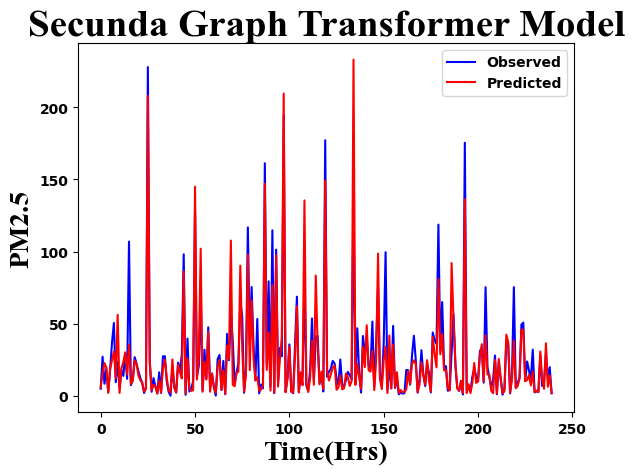

In [32]:
rcParams['font.weight'] = 'bold'
plt.plot(targets[0:240], color='blue', label = 'Observed')
plt.plot(predictions[0:240], color='red', label = 'Predicted')
plt.ylabel('PM2.5', fontname="Times New Roman", size=20,fontweight="bold")
plt.xlabel('Time(Hrs)', fontname="Times New Roman", size=20,fontweight="bold")
plt.title('Secunda Graph Transformer Model', fontname="Times New Roman", size=28,fontweight="bold")
legend_properties = {'weight':'bold'}
plt.legend(prop=legend_properties)
plt.savefig("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/PLOTS/SecGraphTransPred.png", dpi=300, bbox_inches='tight')
plt.show()

# QUANTILE ANALYSIS

In [33]:
print("Performing quantile analysis...")

# Calculate errors
errors = predictions.flatten() - targets

# Calculate quantiles based on actual values
quantiles, bins = pd.qcut(targets, q=10, duplicates='drop', retbins=True)

# Calculate average error for each quantile
quantile_errors = []
for i in range(len(bins) - 1):
    group_indices = np.where((targets >= bins[i]) & (targets < bins[i+1]))[0]
    if len(group_indices) > 0:
        quantile_errors.append(errors[group_indices].mean())

# Round the bin edges for better readability
rounded_bins = np.round(bins, decimals=3)


Performing quantile analysis...


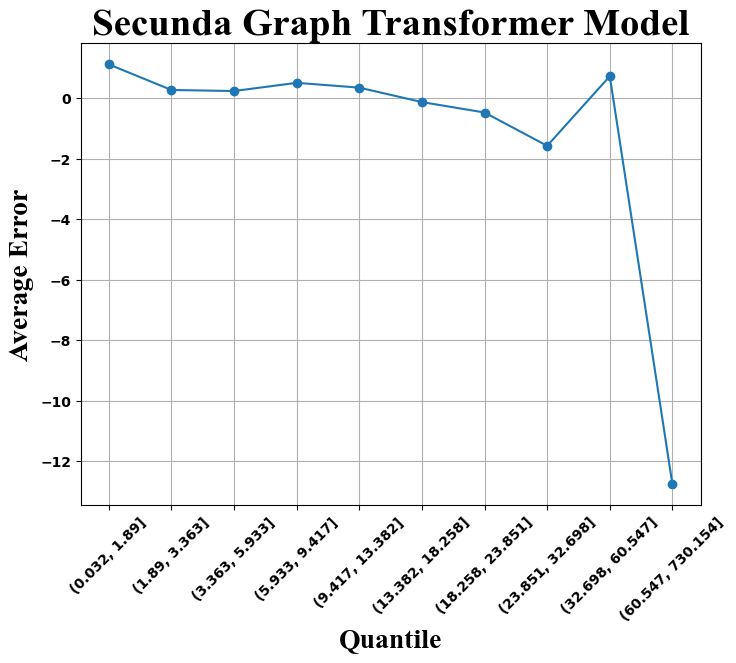

In [34]:
# Plot quantile analysis
# Plot quantiles vs. average errors
rcParams['font.weight'] = 'bold'
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(quantiles.categories) + 1), quantile_errors, marker='o')
plt.xlabel('Quantile', fontname="Times New Roman", size=20,fontweight="bold")
plt.ylabel('Average Error', fontname="Times New Roman", size=20,fontweight="bold")
plt.title('Secunda Graph Transformer Model', fontname="Times New Roman", size=28,fontweight="bold")
plt.xticks(range(1, len(quantiles.categories) + 1), [str(q) for q in quantiles.categories], rotation=45)
plt.grid(True)
plt.savefig("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/PLOTS/SecGraphTransQuan.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
errors = predictions.flatten() - targets

# Calculate quantiles based on actual values
quantiles, bins = pd.qcut(targets, q=10, duplicates='drop', retbins=True)

# Calculate average error for each quantile
quantile_errors = []
for i in range(len(bins) - 1):
    group_indices = np.where((targets >= bins[i]) & (targets < bins[i+1]))[0]
    quantile_errors.append(errors[group_indices].mean())

# Round the bin edges for better readability
rounded_bins = np.round(bins, decimals=3)

# Plot quantiles vs. average errors
rcParams['font.weight'] = 'bold'
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(quantiles.categories) + 1), quantile_errors, marker='o')
plt.xlabel('Quantile', fontname="Times New Roman", size=20, fontweight="bold")
plt.ylabel('Average Error', fontname="Times New Roman", size=20, fontweight="bold")
plt.title('Secunda Graph Transformer Model', fontname="Times New Roman", size=28, fontweight="bold")
plt.xticks(range(1, len(quantiles.categories) + 1), [f'{rounded_bins[i]:.3f} - {rounded_bins[i+1]:.3f}' for i in range(len(rounded_bins) - 1)], rotation=45)
plt.grid(True)
plt.savefig("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/PLOTS/SecGraphTransQuan.png", dpi=300, bbox_inches='tight')
plt.show()

# SHAP ANALYSIS

In [ ]:
print("Performing SHAP analysis...")

try:
    import shap
    
    # Sample a subset for SHAP analysis (computationally expensive)
    n_shap_samples = min(100, len(test_data))
    shap_indices = np.random.choice(len(test_data), n_shap_samples, replace=False)
    shap_data = [test_data[i] for i in shap_indices]
    
    # Create a wrapper function for SHAP that handles graph data
    def model_predict_wrapper(X_flat):
        """Wrapper function to convert flattened input back to graph format for SHAP."""
        predictions = []
        
        # Convert flattened features back to graph format
        for i in range(X_flat.shape[0]):
            # Reshape back to [n_features, seq_length]
            node_features = X_flat[i].reshape(n_features, seq_length)
            
            # Create a sample graph data object
            sample_graph = shap_data[0]  # Use first sample as template
            data = Data(
                x=torch.tensor(node_features, dtype=torch.float32),
                edge_index=sample_graph.edge_index,
                edge_attr=sample_graph.edge_attr,
                batch=torch.zeros(n_features, dtype=torch.long)  # Single graph
            ).to(device)
            
            # Get prediction
            model.eval()
            with torch.no_grad():
                pred = model(data)
                predictions.append(pred.cpu().numpy())
        
        return np.array(predictions)
    
    # Prepare data for SHAP
    # Flatten the graph node features for SHAP analysis
    background_data = []
    test_sample_data = []
    
    for i in range(min(50, len(train_data))):  # Background samples
        node_features = train_data[i].x.numpy()  # [n_features, seq_length]
        background_data.append(node_features.flatten())
    
    for i in range(min(20, len(shap_data))):  # Test samples for explanation
        node_features = shap_data[i].x.numpy()
        test_sample_data.append(node_features.flatten())
    
    background_data = np.array(background_data)
    test_sample_data = np.array(test_sample_data)
    
    # Create SHAP explainer
    print("Creating SHAP explainer (this may take a while)...")
    explainer = shap.KernelExplainer(model_predict_wrapper, background_data[:10])  # Use fewer background samples
    
    # Calculate SHAP values
    print("Calculating SHAP values...")
    shap_values = explainer.shap_values(test_sample_data[:5])  # Analyze fewer test samples
    
    # Create feature names for visualization
    feature_names = []
    for i, col in enumerate(dataset.columns):
        for t in range(seq_length):
            feature_names.append(f"{col}_t{t}")
    
    # Ensure feature names match the flattened data
    if len(feature_names) != test_sample_data.shape[1]:
        feature_names = [f"Feature_{i}" for i in range(test_sample_data.shape[1])]
    
    # Plot SHAP summary
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, test_sample_data[:5], 
                     feature_names=feature_names, show=False, max_display=20)
    plt.title('Secunda Graph Transformer Model', fontweight='bold', size=14)
    plt.tight_layout()
    plt.savefig("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/PLOTS/SecGraphTransShap.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print("SHAP analysis completed successfully!")
    
except ImportError:
    print("SHAP not available. Install with: pip install shap")
except Exception as e:
    print(f"SHAP analysis failed: {e}")
    print("This is normal for complex graph models - SHAP analysis is optional")

# SAVE RESULTS

In [35]:
# Save predictions
results_df = pd.DataFrame({
    'actual': targets,
    'predicted': predictions,
    'error': errors
})
results_df.to_csv('graph_transformer_predictions.csv', index=False)

In [36]:
# Save metrics
metrics_dict = {
    'MSE': mse,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'Training_Time': training_time,
    'Best_Val_Loss': best_val_loss
}

metrics_df = pd.DataFrame([metrics_dict])
metrics_df.to_csv('graph_transformer_metrics.csv', index=False)

In [ ]:
print(f"\n✅ Graph Transformer analysis completed successfully!")
print(f"📁 Results saved in current directory")
print(f"📊 Predictions: 'graph_transformer_predictions.csv'")
print(f"📈 Visualizations: 'graph_transformer_results.png', 'graph_transformer_quantile_analysis.png'")
print(f"🏆 Model saved: 'best_graph_transformer_model.pth'")
print(f"📋 Metrics: 'graph_transformer_metrics.csv'")